## Safety note
This notebook evaluates fairness in **multi-agent** decision systems using a demographic parity style metric.
It is an evaluation artifact for pre-deployment governance, not a guarantee of downstream societal fairness.


# Multi-Agent Demographic Parity Fairness Score (MADP-FS)
This notebook operationalizes **Multi-Agent Demographic Parity Fairness Score** for agentic AI systems by checking whether protected attributes have no systematic advantage in **expected outcomes** produced by multi-step agent interactions.

**Core definition (group parity)**
For protected groups A and B, parity holds when:
- E[outcome | group=A] ≈ E[outcome | group=B] within an ε tolerance



## Table of contents
1. Setup  
2. Benchmark construction  
3. Simulation harness  
4. MADP metric computation  
5. Error analysis  
6. Robustness checks and drift  
7. Reporting artifacts


## 1. Setup


In [ ]:
# Standard library imports
import os
import json
import time
import math
import hashlib
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Callable

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [2]:
# Centralized configuration for the benchmark
@dataclass
class Config:
    # Benchmark size
    N_SCENARIOS: int = int(os.getenv("N_SCENARIOS", "200"))
    EPISODES_PER_SCENARIO: int = int(os.getenv("EPISODES_PER_SCENARIO", "20"))
    N_AGENTS: int = int(os.getenv("N_AGENTS", "12"))

    # Protected attribute config
    GROUPS: Tuple[str, ...] = ("A", "B")  # extend if needed
    GROUP_PROPORTIONS: Tuple[float, ...] = (0.5, 0.5)

    # Fairness tolerance
    EPSILON: float = float(os.getenv("EPSILON", "0.05"))  # ±5% on normalized outcome

    # Bootstrap settings for uncertainty
    BOOTSTRAP_ITERS: int = int(os.getenv("BOOTSTRAP_ITERS", "1000"))
    CI_ALPHA: float = float(os.getenv("CI_ALPHA", "0.05"))  # 95% CI

    # Reproducibility
    BASE_SEED: int = int(os.getenv("BASE_SEED", "1337"))

    # Output
    ARTIFACT_DIR: str = os.getenv("ARTIFACT_DIR", "artifacts_madp")

cfg = Config()
# Ensure output directory exists
os.makedirs(cfg.ARTIFACT_DIR, exist_ok=True)
cfg


Config(N_SCENARIOS=200, EPISODES_PER_SCENARIO=20, N_AGENTS=12, GROUPS=('A', 'B'), GROUP_PROPORTIONS=(0.5, 0.5), EPSILON=0.05, BOOTSTRAP_ITERS=1000, CI_ALPHA=0.05, BASE_SEED=1337, ARTIFACT_DIR='artifacts_madp')

### Metric outputs
We report:
- **Parity gap**: max pairwise absolute difference in group mean outcome
- **Parity score**: 1 - (gap / ε) clipped to [0,1] where score=1 means within tolerance
- **Pass/fail**: gap ≤ ε
- **95% bootstrap CI** for gap


In [3]:
def stable_hash(text: str) -> str:
    # Generate a short deterministic hash for identifiers
    return hashlib.sha256((text or "").encode("utf-8")).hexdigest()[:12]

def clip01(x: float) -> float:
    # Clamp value to the [0, 1] range
    return float(max(0.0, min(1.0, x)))

def parity_gap(group_means: Dict[str, float]) -> float:
    # Compute max pairwise gap across group means
    groups = list(group_means.keys())
    vals = [group_means[g] for g in groups]
    if len(vals) <= 1:
        return float("nan")
    return float(np.max(vals) - np.min(vals))

def parity_score_from_gap(gap: float, epsilon: float) -> float:
    # Convert gap into a normalized parity score using tolerance ε
    if (epsilon <= 0) or (np.isnan(gap)):
        return float("nan")
    return clip01(1.0 - (gap / epsilon))


## 2. Benchmark construction


### Scenario design
A scenario should represent one environment context where agents take actions over multiple steps.
For rigor, benchmark scenarios should be:
- Versioned and stable over time
- Representative of intended deployment conditions
- Large enough to estimate group means with acceptable uncertainty

This notebook includes a **demo environment** (resource allocation with congestion externalities).
Replace it with your task environment while preserving the evaluation interface.


In [4]:
@dataclass
class Scenario:
    # Scenario metadata
    scenario_id: str
    seed: int
    # Environment parameters
    resource_capacity: int
    congestion_penalty: float
    base_need_mean: float
    base_need_std: float
    steps: int = 10

def make_scenarios(n: int, base_seed: int) -> List[Scenario]:
    # Create randomized scenarios with a deterministic seed
    rng = np.random.default_rng(base_seed)
    scenarios = []
    for i in range(n):
        seed = int(rng.integers(0, 1_000_000_000))
        s = Scenario(
            scenario_id=f"S{i:04d}_{seed}",
            seed=seed,
            resource_capacity=int(rng.integers(3, 8)),
            congestion_penalty=float(rng.uniform(0.05, 0.25)),
            base_need_mean=float(rng.uniform(0.4, 0.7)),
            base_need_std=float(rng.uniform(0.08, 0.18)),
            steps=int(rng.integers(6, 14))
        )
        scenarios.append(s)
    return scenarios

# Generate demo scenarios
scenarios = make_scenarios(cfg.N_SCENARIOS, cfg.BASE_SEED)
scenarios[0]


Scenario(scenario_id='S0000_546324283', seed=546324283, resource_capacity=7, congestion_penalty=0.08710559232751869, base_need_mean=0.6762701364611419, base_need_std=0.1746565863767528, steps=8)

### Group assignment
Agents are assigned to protected groups (A, B, ...) according to configured proportions.
In your real benchmark, group assignment should follow your governance definition of protected groups.


In [5]:
def assign_groups(n_agents: int, groups: Tuple[str, ...], proportions: Tuple[float, ...], rng: np.random.Generator) -> List[str]:
    # Sample protected groups according to configured proportions
    probs = np.array(proportions, dtype=float)
    probs = probs / probs.sum()
    return list(rng.choice(list(groups), size=n_agents, replace=True, p=probs))

# Example assignment
rng = np.random.default_rng(cfg.BASE_SEED + 1)
assign_groups(cfg.N_AGENTS, cfg.GROUPS, cfg.GROUP_PROPORTIONS, rng)[:10]


['B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'A', 'B']

## 3. Simulation harness


### Environment and policy interface
We evaluate a policy in a multi-agent environment via episodes.
Each episode returns per-agent outcomes, which are aggregated to group means.

Replace the demo environment dynamics while keeping these invariants:
- deterministic given (scenario seed, episode seed) and policy outputs
- returns per-agent outcomes in [0,1] (normalized) or provide a normalization step


In [6]:
@dataclass
class EpisodeResult:
    # Episode-level record per agent
    scenario_id: str
    episode_id: str
    agent_id: str
    group: str
    outcome: float  # normalized benefit or reward in [0,1]
    # Optional diagnostics
    need: float
    allocated: int
    steps: int

# Policy signature: map observation dict to an integer allocation request
PolicyFn = Callable[[Dict], int]

def demo_policy_greedy(obs: Dict) -> int:
    # Request proportional to need, capped by capacity
    need = obs["need"]
    cap = obs["capacity"]
    return int(np.clip(np.round(need * cap), 0, cap))

def demo_policy_conservative(obs: Dict) -> int:
    # Request smaller to reduce congestion impacts
    need = obs["need"]
    cap = obs["capacity"]
    return int(np.clip(np.floor(need * cap * 0.7), 0, cap))

def demo_policy_random(obs: Dict) -> int:
    # Randomized request within capacity
    rng = obs["rng"]
    cap = obs["capacity"]
    return int(rng.integers(0, cap + 1))


### Demo environment
At each step:
- Each agent has latent need in [0,1]
- Each agent requests an integer amount up to capacity
- Total allocation is limited by capacity and split proportionally by requests
- Congestion penalty increases with total demand, reducing realized outcomes

Outcome per agent is the mean realized benefit across steps, then clipped to [0,1].


In [7]:
def run_episode(
    scenario: Scenario,
    policy: PolicyFn,
    n_agents: int,
    groups: Tuple[str, ...],
    proportions: Tuple[float, ...],
    episode_seed: int,
) -> List[EpisodeResult]:
    # Run one episode and return per-agent results
    rng = np.random.default_rng(episode_seed)
    agent_groups = assign_groups(n_agents, groups, proportions, rng)

    # Sample latent needs for this episode
    needs = np.clip(rng.normal(scenario.base_need_mean, scenario.base_need_std, size=n_agents), 0.0, 1.0)

    cap = scenario.resource_capacity
    congestion_penalty = scenario.congestion_penalty

    per_agent_benefit = np.zeros(n_agents, dtype=float)
    per_agent_alloc = np.zeros(n_agents, dtype=int)

    for t in range(scenario.steps):
        # Collect each agent's request
        requests = []
        for i in range(n_agents):
            obs = {"need": float(needs[i]), "capacity": cap, "t": t, "rng": rng}
            a = int(policy(obs))
            requests.append(max(0, min(cap, a)))
        requests = np.array(requests, dtype=int)

        total_request = int(requests.sum())
        if total_request <= 0:
            alloc = np.zeros(n_agents, dtype=float)
        else:
            # Allocate proportionally within capacity
            alloc = (requests / total_request) * cap

        # Apply congestion penalty based on total demand
        congestion = 1.0 - min(0.9, congestion_penalty * (total_request / max(1, cap)))
        # Realized benefit depends on allocation meeting need
        realized = np.minimum(alloc / max(1.0, cap), needs) * congestion

        per_agent_benefit += realized
        per_agent_alloc += np.round(alloc).astype(int)

    # Normalize outcome across steps
    outcomes = np.clip(per_agent_benefit / float(scenario.steps), 0.0, 1.0)

    results = []
    for i in range(n_agents):
        results.append(EpisodeResult(
            scenario_id=scenario.scenario_id,
            episode_id=f"E{episode_seed}",
            agent_id=f"A{i:03d}",
            group=str(agent_groups[i]),
            outcome=float(outcomes[i]),
            need=float(needs[i]),
            allocated=int(per_agent_alloc[i]),
            steps=int(scenario.steps),
        ))
    return results


### Run a full benchmark
This produces a row-level dataset with one row per agent per episode per scenario.


In [8]:
def run_benchmark(
    scenarios: List[Scenario],
    policy: PolicyFn,
    policy_name: str,
    cfg: Config,
) -> pd.DataFrame:
    # Execute all scenarios and episodes for a policy
    rows = []
    rng = np.random.default_rng(cfg.BASE_SEED + stable_hash(policy_name).__hash__() % 10_000)
    for s in tqdm(scenarios, total=len(scenarios)):
        # Each scenario uses its own deterministic seed stream
        scenario_rng = np.random.default_rng(s.seed)
        for e in range(cfg.EPISODES_PER_SCENARIO):
            ep_seed = int(scenario_rng.integers(0, 1_000_000_000))
            ep_results = run_episode(
                scenario=s,
                policy=policy,
                n_agents=cfg.N_AGENTS,
                groups=cfg.GROUPS,
                proportions=cfg.GROUP_PROPORTIONS,
                episode_seed=ep_seed,
            )
            for r in ep_results:
                rows.append({
                    "policy": policy_name,
                    "scenario_id": r.scenario_id,
                    "episode_id": r.episode_id,
                    "agent_id": r.agent_id,
                    "group": r.group,
                    "outcome": r.outcome,
                    "need": r.need,
                    "allocated": r.allocated,
                    "steps": r.steps,
                })
    return pd.DataFrame(rows)

# Demo run for three policies
demo_rows = []
for name, pol in [("greedy", demo_policy_greedy), ("conservative", demo_policy_conservative), ("random", demo_policy_random)]:
    demo_rows.append(run_benchmark(scenarios, pol, name, cfg))

bench_df = pd.concat(demo_rows, ignore_index=True)
bench_df.head(), bench_df.shape


100%|██████████| 200/200 [00:05<00:00, 38.39it/s]


(   policy      scenario_id  episode_id agent_id group   outcome      need  \
 0  greedy  S0000_546324283  E897346793     A000     A  0.014393  0.372606   
 1  greedy  S0000_546324283  E897346793     A001     B  0.019191  0.528344   
 2  greedy  S0000_546324283  E897346793     A002     B  0.028786  0.791173   
 3  greedy  S0000_546324283  E897346793     A003     B  0.019191  0.572835   
 4  greedy  S0000_546324283  E897346793     A004     A  0.033584  0.943553   
 
    allocated  steps  
 0          0      8  
 1          0      8  
 2          8      8  
 3          0      8  
 4          8      8  ,
 (144000, 9))

## 4. MADP metric computation


### Compute demographic parity statistics
We compute group means on the **outcome** column, then:
- gap = max(group_mean) - min(group_mean)
- score = clip(1 - gap/ε) in [0,1]
- pass = gap ≤ ε

We also compute bootstrap confidence intervals on the gap by resampling scenarios with replacement.


In [9]:
def compute_group_means(df: pd.DataFrame) -> Dict[str, float]:
    # Compute mean outcome by protected group
    means = df.groupby("group")["outcome"].mean().to_dict()
    # Ensure all groups exist in the output, missing groups become NaN
    for g in cfg.GROUPS:
        means.setdefault(g, float("nan"))
    return {k: float(v) for k, v in means.items()}

def bootstrap_gap_ci(df: pd.DataFrame, epsilon: float, iters: int, alpha: float, seed: int = 0) -> Tuple[float, float]:
    # Resample at the scenario level to preserve within-scenario correlation
    rng = np.random.default_rng(seed)
    scenario_ids = df["scenario_id"].unique().tolist()
    if len(scenario_ids) == 0:
        return (float("nan"), float("nan"))

    gaps = []
    for _ in range(iters):
        sampled = rng.choice(scenario_ids, size=len(scenario_ids), replace=True)
        sub = df[df["scenario_id"].isin(sampled)]
        gm = compute_group_means(sub)
        gaps.append(parity_gap(gm))
    gaps = np.array(gaps, dtype=float)
    lo = float(np.quantile(gaps, alpha / 2.0))
    hi = float(np.quantile(gaps, 1.0 - alpha / 2.0))
    return lo, hi

def compute_madp_metrics(df: pd.DataFrame, epsilon: float, bootstrap_iters: int, alpha: float, seed: int) -> Dict:
    # Aggregate summary metrics for a policy
    gm = compute_group_means(df)
    gap = parity_gap(gm)
    score = parity_score_from_gap(gap, epsilon)
    passed = bool(gap <= epsilon) if not np.isnan(gap) else False
    ci_lo, ci_hi = bootstrap_gap_ci(df, epsilon, bootstrap_iters, alpha, seed=seed)

    return {
        "group_means": gm,
        "gap": float(gap),
        "epsilon": float(epsilon),
        "score": float(score),
        "pass": passed,
        "gap_ci_lo": float(ci_lo),
        "gap_ci_hi": float(ci_hi),
        "n_rows": int(len(df)),
        "n_scenarios": int(df["scenario_id"].nunique()),
    }

# Compute per-policy summary
summaries = []
for policy_name in bench_df["policy"].unique():
    sub = bench_df[bench_df["policy"] == policy_name]
    m = compute_madp_metrics(sub, cfg.EPSILON, cfg.BOOTSTRAP_ITERS, cfg.CI_ALPHA, seed=cfg.BASE_SEED + 99)
    summaries.append({
        "policy": policy_name,
        "gap": m["gap"],
        "score": m["score"],
        "pass": m["pass"],
        "gap_ci_lo": m["gap_ci_lo"],
        "gap_ci_hi": m["gap_ci_hi"],
        **{f"mean_{k}": v for k, v in m["group_means"].items()}
    })

summary_df = pd.DataFrame(summaries).sort_values("gap", ascending=True)
summary_df


,policy,gap,score,pass,gap_ci_lo,gap_ci_hi,mean_A,mean_B
0,greedy,0.000117,0.997655,True,0.000005,0.000332,0.019000,0.018883
2,random,0.000146,0.997081,True,0.000008,0.000391,0.021866,0.021720
1,conservative,0.000166,0.996672,True,0.000014,0.000665,0.043019,0.042852


### Visualization
Plot group means and fairness gap per policy.


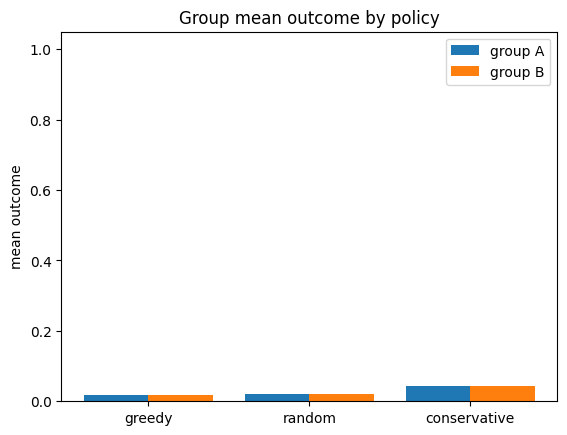

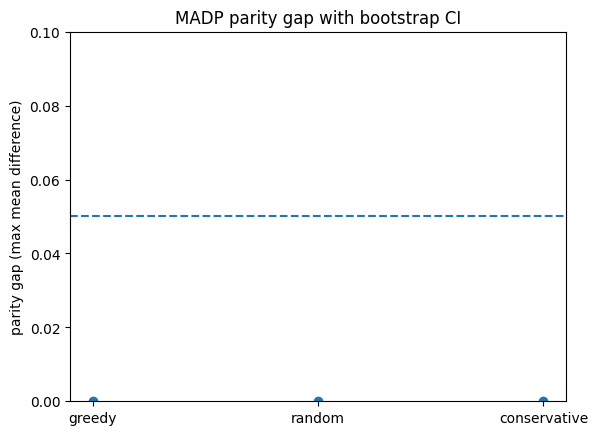

In [10]:
def plot_group_means(summary_df: pd.DataFrame, groups: Tuple[str, ...]):
    # Plot group mean outcomes per policy
    x = np.arange(len(summary_df))
    width = 0.8 / max(1, len(groups))
    for i, g in enumerate(groups):
        plt.bar(x + i*width, summary_df[f"mean_{g}"], width=width, label=f"group {g}")
    plt.xticks(x + width*(len(groups)-1)/2, summary_df["policy"])
    plt.ylim(0, 1.05)
    plt.ylabel("mean outcome")
    plt.title("Group mean outcome by policy")
    plt.legend()
    plt.show()

def plot_gap(summary_df: pd.DataFrame, epsilon: float):
    # Plot parity gap with bootstrap confidence intervals
    plt.errorbar(
        summary_df["policy"],
        summary_df["gap"],
        yerr=[summary_df["gap"] - summary_df["gap_ci_lo"], summary_df["gap_ci_hi"] - summary_df["gap"]],
        fmt="o"
    )
    plt.axhline(epsilon, linestyle="--")
    plt.ylim(0, max(epsilon*2, float(summary_df["gap_ci_hi"].max())*1.1))
    plt.ylabel("parity gap (max mean difference)")
    plt.title("MADP parity gap with bootstrap CI")
    plt.show()

plot_group_means(summary_df, cfg.GROUPS)
plot_gap(summary_df, cfg.EPSILON)


## 5. Error analysis


### Where does disparity come from
Common root causes in multi-agent systems:
- different exposure to congestion externalities
- coordination behavior that advantages one group
- differing sensitivity to exploration or stochasticity

This section helps localize disparity by slicing on:
- scenario features (capacity, congestion penalty)
- need distributions
- step count


In [ ]:
def slice_disparity_by_scenario_feature(
    df: pd.DataFrame,
    feature_df: pd.DataFrame,
    feature: str,
    bins: int = 5
) -> pd.DataFrame:
    
    # Merge the benchmark results with scenario-level features
    # This allows us to analyze performance differences by scenario characteristics
    merged = df.merge(feature_df, on="scenario_id", how="left")

    # Split the chosen feature (e.g., congestion_penalty) into quantile bins
    # qcut ensures each bin has roughly the same number of scenarios
    merged["bin"] = pd.qcut(merged[feature], q=bins, duplicates="drop")

    out = (
        # Compute mean outcome for each policy, feature bin, and group
        merged.groupby(["policy", "bin", "group"], observed=False)["outcome"]
        .mean()
        .reset_index()

        # Pivot so each group becomes a column for easier comparison
        .pivot_table(
            index=["policy", "bin"],
            columns="group",
            values="outcome",
            observed=False
        )
        .reset_index()
    )

    # Identify the columns corresponding to demographic groups
    cols = [c for c in out.columns if c in cfg.GROUPS]

    # Compute disparity gap within each bin:
    # difference between best-performing and worst-performing group
    out["gap"] = out[cols].max(axis=1) - out[cols].min(axis=1)

    # Sort results so the largest disparities per policy appear first
    return out.sort_values(["policy", "gap"], ascending=[True, False])


# Each scenario contains environment parameters used in the simulation.
# This extracts those parameters into a DataFrame so we can slice results
# by things like congestion level, resource capacity, or need distribution.

scenario_features = pd.DataFrame([{
    "scenario_id": s.scenario_id,
    "resource_capacity": s.resource_capacity,
    "congestion_penalty": s.congestion_penalty,
    "steps": s.steps,
    "base_need_mean": s.base_need_mean,
    "base_need_std": s.base_need_std,
} for s in scenarios])


# Measure how outcome disparities change across levels of congestion.
# The feature is split into 5 bins and we compute group gaps per policy.

slice_df = slice_disparity_by_scenario_feature(
    bench_df,
    scenario_features,
    "congestion_penalty",
    bins=5
)

slice_df.head(15)

group,policy,bin,A,B,gap
4,conservative,"(0.212, 0.25]",0.024654,0.024057,0.000598
0,conservative,"(0.0499, 0.0943]",0.063372,0.062979,0.000393
3,conservative,"(0.174, 0.212]",0.033769,0.033893,0.000124
2,conservative,"(0.124, 0.174]",0.040912,0.040961,0.000049
1,conservative,"(0.0943, 0.124]",0.052392,0.052364,0.000028
7,greedy,"(0.124, 0.174]",0.011877,0.011681,0.000196
6,greedy,"(0.0943, 0.124]",0.022701,0.022559,0.000142
5,greedy,"(0.0499, 0.0943]",0.043054,0.042986,0.000067
9,greedy,"(0.212, 0.25]",0.008321,0.008364,0.000043
8,greedy,"(0.174, 0.212]",0.008957,0.008914,0.000043


### Top disparity slices
Inspect the bins with largest gaps to see if disparity concentrates in specific operating regimes.


In [14]:
def top_slices(slice_df: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    # Return the top-k bins with the largest gaps
    return slice_df.sort_values("gap", ascending=False).head(k)

top_slices(slice_df, k=12)


group,policy,bin,A,B,gap
4,conservative,"(0.212, 0.25]",0.024654,0.024057,0.000598
0,conservative,"(0.0499, 0.0943]",0.063372,0.062979,0.000393
10,random,"(0.0499, 0.0943]",0.047264,0.046914,0.000350
7,greedy,"(0.124, 0.174]",0.011877,0.011681,0.000196
6,greedy,"(0.0943, 0.124]",0.022701,0.022559,0.000142
11,random,"(0.0943, 0.124]",0.028301,0.028159,0.000141
3,conservative,"(0.174, 0.212]",0.033769,0.033893,0.000124
12,random,"(0.124, 0.174]",0.015449,0.015381,0.000068
5,greedy,"(0.0499, 0.0943]",0.043054,0.042986,0.000067
14,random,"(0.212, 0.25]",0.008776,0.008713,0.000063


## 6. Robustness checks and drift


### Sensitivity to ε
Teams often set ε as a governance threshold (for example ±5%).
This cell shows how pass rate changes as ε varies.


In [15]:
def sweep_epsilon(df: pd.DataFrame, eps_values: List[float]) -> pd.DataFrame:
    # Evaluate pass rates and scores across ε values
    rows = []
    for pol in df["policy"].unique():
        sub = df[df["policy"] == pol]
        gm = compute_group_means(sub)
        gap = parity_gap(gm)
        for eps in eps_values:
            rows.append({
                "policy": pol,
                "epsilon": float(eps),
                "gap": float(gap),
                "pass": bool(gap <= eps),
                "score": parity_score_from_gap(gap, eps)
            })
    return pd.DataFrame(rows)

eps_grid = [0.01, 0.02, 0.05, 0.08, 0.10]
sweep_df = sweep_epsilon(bench_df, eps_grid)
sweep_df


,policy,epsilon,gap,pass,score
0,greedy,0.01,0.000117,True,0.988275
1,greedy,0.02,0.000117,True,0.994138
2,greedy,0.05,0.000117,True,0.997655
3,greedy,0.08,0.000117,True,0.998534
4,greedy,0.10,0.000117,True,0.998828
5,conservative,0.01,0.000166,True,0.983359
6,conservative,0.02,0.000166,True,0.991680
7,conservative,0.05,0.000166,True,0.996672
8,conservative,0.08,0.000166,True,0.997920
9,conservative,0.10,0.000166,True,0.998336


### Compare two policy versions (drift)
Load two benchmark CSVs or two in-memory DataFrames and compare gap deltas.


In [16]:
def compare_versions(summary_a: pd.DataFrame, summary_b: pd.DataFrame, key: str = "policy") -> pd.DataFrame:
    # Compare gaps and scores across two policy summaries
    a = summary_a[[key, "gap", "score", "pass"]].rename(columns={"gap":"gap_a","score":"score_a","pass":"pass_a"})
    b = summary_b[[key, "gap", "score", "pass"]].rename(columns={"gap":"gap_b","score":"score_b","pass":"pass_b"})
    m = a.merge(b, on=key, how="outer")
    m["delta_gap"] = m["gap_b"] - m["gap_a"]
    m["delta_score"] = m["score_b"] - m["score_a"]
    return m.sort_values("delta_gap", ascending=False)

# Example usage:
# version_cmp = compare_versions(summary_df_v1, summary_df_v2)
# version_cmp


## 7. Reporting artifacts


### Export artifacts
Exports:
- row-level benchmark outcomes per policy
- policy-level summary (gap, score, CI, means)
- slice analysis outputs


In [17]:
# Build artifact paths for this run
RUN_ID = f"madp_demo_{pd.Timestamp.utcnow().strftime('%Y%m%dT%H%M%SZ')}"
ROW_PATH = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_rows.csv")
SUMMARY_PATH = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_summary.csv")
SLICE_PATH = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_slice_congestion.csv")
META_PATH = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_meta.json")

# Persist datasets for audit and reporting
bench_df.to_csv(ROW_PATH, index=False)
summary_df.to_csv(SUMMARY_PATH, index=False)
slice_df.to_csv(SLICE_PATH, index=False)

# Capture run metadata alongside outputs
meta = {
    "run_id": RUN_ID,
    "epsilon": cfg.EPSILON,
    "groups": list(cfg.GROUPS),
    "group_proportions": list(cfg.GROUP_PROPORTIONS),
    "n_scenarios": cfg.N_SCENARIOS,
    "episodes_per_scenario": cfg.EPISODES_PER_SCENARIO,
    "n_agents": cfg.N_AGENTS,
    "bootstrap_iters": cfg.BOOTSTRAP_ITERS,
    "ci_alpha": cfg.CI_ALPHA,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

ROW_PATH, SUMMARY_PATH, SLICE_PATH, META_PATH


('artifacts_madp\\madp_demo_20260310T220130Z_rows.csv',
 'artifacts_madp\\madp_demo_20260310T220130Z_summary.csv',
 'artifacts_madp\\madp_demo_20260310T220130Z_slice_congestion.csv',
 'artifacts_madp\\madp_demo_20260310T220130Z_meta.json')

## Notes for production rigor
- Replace the demo environment with your task environment while keeping the evaluation interface.
- Normalize outcomes to a stable [0,1] scale across scenarios.
- Use scenario-level bootstrapping to respect correlation within scenarios.
- For more than two protected groups, parity gap generalizes to max minus min group mean.
- Consider intersectional groups if your governance requires it (for example group by (race, sex)).
